In [1]:
import pandas as pd

df1 = pd.read_csv('/kaggle/input/topfacialregions/top_facial_regions_dataset.csv')
df2 = pd.read_csv('/kaggle/input/mfcc-of-slurred-vocal/MFCCoutput.csv')

In [2]:
print("Face CSV file:")
df1.head()

Face CSV file:


,lipsUpperOuter_61,lipsUpperOuter_185,lipsUpperOuter_40,lipsUpperOuter_39,lipsUpperOuter_37,lipsUpperOuter_0,lipsUpperOuter_267,lipsUpperOuter_269,lipsUpperOuter_270,lipsUpperOuter_409,...,leftCheek_436,leftCheek_416,leftCheek_432,leftCheek_434,leftCheek_422,leftCheek_430,leftCheek_364,leftCheek_394,leftCheek_371,is_stroke_face
0,-0.796998,-0.783761,-0.854249,-1.005285,-1.792751,-29.106225,2.036443,1.081125,0.908469,0.832174,...,0.436471,0.406742,0.624146,0.561062,0.876275,0.871828,0.710128,0.976405,-0.134716,1
1,-0.642420,-0.637615,-0.723670,-0.889811,-1.550794,-6.475804,3.615617,1.600363,1.280204,1.130504,...,0.617774,0.618373,0.926578,0.853487,1.379093,1.413742,1.122774,1.634850,-0.205107,1
2,-0.788563,-0.800038,-0.889967,-1.072733,-2.086448,9.135111,1.369078,0.754315,0.631121,0.568725,...,0.186183,0.158452,0.354429,0.293867,0.554730,0.543838,0.411882,0.618886,-0.595886,1
3,-2.699764,-2.638462,-2.861563,-3.422442,-7.638168,12.177414,3.140405,1.905193,1.654674,1.538375,...,0.778128,0.764361,1.228064,1.113862,1.775543,1.800757,1.456326,2.028305,-0.741644,1
4,-0.570210,-0.582949,-0.669734,-0.824996,-1.521187,-13.638438,2.015914,0.966277,0.770261,0.666191,...,0.255883,0.230079,0.448418,0.385427,0.694891,0.692805,0.522984,0.789427,-0.455395,1


In [3]:
print("\nMFCC CSV file:")
df2.head()


MFCC CSV file:


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,119,120,121,122,123,124,125,126,127,class
0,0,-398.97055,92.846680,-6.212745,19.836878,-3.015201,9.478265,5.134083,6.716100,1.437088,...,0.018726,-0.244671,-0.650705,-0.262222,0.137795,-0.539087,-0.257223,-0.230522,-0.188446,1.0
1,1,-232.39255,115.044525,-21.028315,39.190132,-17.016842,7.619745,-2.724971,4.140653,-1.230497,...,0.197640,0.564010,0.166091,-0.022294,0.257573,0.168772,0.264451,-0.257519,-0.390595,1.0
2,2,-466.48450,89.272385,-8.458461,30.776363,-11.168960,18.305796,0.989266,10.417193,0.574027,...,0.232031,0.074036,0.237405,0.154122,0.281900,0.768758,-0.073312,0.096406,0.285212,1.0
3,3,-466.73505,62.805060,12.439709,29.304922,12.614448,9.676723,1.418015,13.074185,0.037665,...,0.408432,-0.018611,-0.274066,0.071348,0.231881,0.456909,0.000649,-0.379244,-0.105873,1.0
4,4,-426.44970,80.985410,-4.792509,36.350883,-0.092283,19.156744,-5.060070,10.123955,2.196594,...,-0.064134,0.120973,0.070115,0.138273,0.084424,0.080933,-0.295089,-0.199056,0.120445,1.0


In [4]:
df1.shape

(1996, 116)

In [5]:
df2.shape

(4314, 130)

In [6]:
# Trim 6 rows
def trim_rows_balanced(df, target_col, rows_to_remove):
    class_counts = df[target_col].value_counts()
    total = class_counts.sum()
    
    
    remove_counts = (class_counts / total * rows_to_remove).round().astype(int)
    
   
    while remove_counts.sum() != rows_to_remove:
        diff = rows_to_remove - remove_counts.sum()
        max_class = remove_counts.idxmax() if diff > 0 else remove_counts.idxmin()
        remove_counts[max_class] += 1 if diff > 0 else -1

  
    indices_to_remove = []
    for cls, n_remove in remove_counts.items():
        indices = df[df[target_col] == cls].sample(n=n_remove, random_state=42).index
        indices_to_remove.extend(indices)

    return df.drop(index=indices_to_remove)

df1_trimmed = trim_rows_balanced(df1, target_col='is_stroke_face', rows_to_remove=6)

# Trim df2 to 1990 rows with equal class distribution
def balance_to_n_rows(df, target_col, total_rows):
    unique_classes = df[target_col].unique()
    n_classes = len(unique_classes)
    n_per_class = total_rows // n_classes

    # Sample n_per_class from each class
    balanced_df = df.groupby(target_col).sample(n=n_per_class, random_state=42)
    
    return balanced_df

df2_trimmed = balance_to_n_rows(df2, target_col='class', total_rows=1990)


print("df1_trimmed shape:", df1_trimmed.shape)
print("df1_trimmed class distribution:\n", df1_trimmed['is_stroke_face'].value_counts())

print("\ndf2_trimmed shape:", df2_trimmed.shape)
print("df2_trimmed class distribution:\n", df2_trimmed['class'].value_counts())

df1_trimmed shape: (1990, 116)
df1_trimmed class distribution:
 is_stroke_face
1    995
0    995
Name: count, dtype: int64

df2_trimmed shape: (1990, 130)
df2_trimmed class distribution:
 class
0.0    995
1.0    995
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and targets
X_df1 = df1_trimmed.drop(columns=['is_stroke_face'])
y_df1 = df1_trimmed['is_stroke_face']

X_df2 = df2_trimmed.drop(columns=['class'])
y_df2 = df2_trimmed['class']

# Scaling
scaler = MinMaxScaler()


X_df1_scaled = scaler.fit_transform(X_df1)
X_df2_scaled = scaler.fit_transform(X_df2)


X_df1_scaled = pd.DataFrame(X_df1_scaled, columns=X_df1.columns)
X_df2_scaled = pd.DataFrame(X_df2_scaled, columns=X_df2.columns)


df1_scaled = pd.concat([X_df1_scaled, y_df1.reset_index(drop=True)], axis=1)
df2_scaled = pd.concat([X_df2_scaled, y_df2.reset_index(drop=True)], axis=1)

In [8]:
df1_scaled.head()

,lipsUpperOuter_61,lipsUpperOuter_185,lipsUpperOuter_40,lipsUpperOuter_39,lipsUpperOuter_37,lipsUpperOuter_0,lipsUpperOuter_267,lipsUpperOuter_269,lipsUpperOuter_270,lipsUpperOuter_409,...,leftCheek_436,leftCheek_416,leftCheek_432,leftCheek_434,leftCheek_422,leftCheek_430,leftCheek_364,leftCheek_394,leftCheek_371,is_stroke_face
0,0.881892,0.447948,0.915568,0.562871,0.089069,0.589250,0.217464,0.307646,0.042146,0.067414,...,0.381357,0.312092,0.288162,0.295674,0.105066,0.106496,0.155501,0.472941,0.476629,1
1,0.883030,0.450550,0.915943,0.563874,0.089116,0.591155,0.221953,0.311974,0.050797,0.079354,...,0.434563,0.388227,0.345782,0.362441,0.135429,0.140510,0.204020,0.479105,0.469896,1
2,0.881954,0.447658,0.915465,0.562286,0.089012,0.592470,0.215567,0.304922,0.035691,0.056870,...,0.307906,0.222769,0.236775,0.234668,0.085650,0.085909,0.120433,0.469594,0.432517,1
3,0.867880,0.414930,0.909804,0.541894,0.087934,0.592726,0.220602,0.314515,0.059513,0.095679,...,0.481622,0.440747,0.403222,0.421890,0.159369,0.164802,0.243240,0.482789,0.418575,1
4,0.883562,0.451523,0.916097,0.564436,0.089122,0.590552,0.217406,0.306689,0.038929,0.060771,...,0.328361,0.248537,0.254682,0.255573,0.094113,0.095259,0.133496,0.471190,0.445955,1


In [9]:
df2_scaled.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,119,120,121,122,123,124,125,126,127,class
0,0.536302,0.601901,0.482608,0.610757,0.579699,0.721039,0.204581,0.606454,0.540917,0.414135,...,0.599252,0.262921,0.363788,0.407719,0.331333,0.427933,0.466653,0.326348,0.647691,0.0
1,0.442589,0.587872,0.521329,0.499518,0.568676,0.559037,0.166080,0.591625,0.602790,0.456923,...,0.593768,0.343767,0.290886,0.350176,0.399154,0.423917,0.535039,0.326310,0.459253,0.0
2,0.191835,0.714571,0.525024,0.439274,0.576673,0.593385,0.246846,0.514828,0.505624,0.287968,...,0.561957,0.349986,0.434392,0.407714,0.394009,0.434438,0.492717,0.291844,0.498591,0.0
3,0.810949,0.553675,0.439952,0.429272,0.611373,0.485428,0.520185,0.593573,0.615606,0.519796,...,0.560628,0.391700,0.539348,0.327748,0.302793,0.243995,0.504189,0.225660,0.442423,0.0
4,0.350267,0.622697,0.635584,0.465590,0.637734,0.517850,0.512718,0.492663,0.674333,0.457739,...,0.555854,0.329498,0.479381,0.295203,0.291714,0.258956,0.487118,0.158921,0.345040,0.0


In [10]:
df2_scaled = df2_scaled.rename(columns={'class': 'is_stroke_face'})

In [11]:
df2_scaled.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,119,120,121,122,123,124,125,126,127,is_stroke_face
0,0.536302,0.601901,0.482608,0.610757,0.579699,0.721039,0.204581,0.606454,0.540917,0.414135,...,0.599252,0.262921,0.363788,0.407719,0.331333,0.427933,0.466653,0.326348,0.647691,0.0
1,0.442589,0.587872,0.521329,0.499518,0.568676,0.559037,0.166080,0.591625,0.602790,0.456923,...,0.593768,0.343767,0.290886,0.350176,0.399154,0.423917,0.535039,0.326310,0.459253,0.0
2,0.191835,0.714571,0.525024,0.439274,0.576673,0.593385,0.246846,0.514828,0.505624,0.287968,...,0.561957,0.349986,0.434392,0.407714,0.394009,0.434438,0.492717,0.291844,0.498591,0.0
3,0.810949,0.553675,0.439952,0.429272,0.611373,0.485428,0.520185,0.593573,0.615606,0.519796,...,0.560628,0.391700,0.539348,0.327748,0.302793,0.243995,0.504189,0.225660,0.442423,0.0
4,0.350267,0.622697,0.635584,0.465590,0.637734,0.517850,0.512718,0.492663,0.674333,0.457739,...,0.555854,0.329498,0.479381,0.295203,0.291714,0.258956,0.487118,0.158921,0.345040,0.0


In [12]:
target = df2_scaled['is_stroke_face']
df2_scaled = df2_scaled.iloc[:, :-15]
df2_scaled['is_stroke_face'] = target

In [13]:
df2_scaled.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,105,106,107,108,109,110,111,112,113,is_stroke_face
0,0.536302,0.601901,0.482608,0.610757,0.579699,0.721039,0.204581,0.606454,0.540917,0.414135,...,0.342168,0.710827,0.798244,0.630845,0.553211,0.515454,0.521476,0.355670,0.324944,0.0
1,0.442589,0.587872,0.521329,0.499518,0.568676,0.559037,0.166080,0.591625,0.602790,0.456923,...,0.452279,0.629255,0.761536,0.599253,0.595418,0.587362,0.450338,0.310522,0.362974,0.0
2,0.191835,0.714571,0.525024,0.439274,0.576673,0.593385,0.246846,0.514828,0.505624,0.287968,...,0.413332,0.636308,0.750825,0.681894,0.646518,0.549043,0.437233,0.217753,0.302565,0.0
3,0.810949,0.553675,0.439952,0.429272,0.611373,0.485428,0.520185,0.593573,0.615606,0.519796,...,0.517568,0.463580,0.586498,0.318070,0.521843,0.694026,0.700944,0.645480,0.522206,0.0
4,0.350267,0.622697,0.635584,0.465590,0.637734,0.517850,0.512718,0.492663,0.674333,0.457739,...,0.473717,0.434687,0.569038,0.339675,0.457413,0.639558,0.609734,0.460241,0.421763,0.0


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# target labels are aligned
y = df1_scaled['is_stroke_face'].values 

# Features for landmark and MFCC
X_landmark = df1_scaled.drop(columns=['is_stroke_face']).values
X_mfcc = df2_scaled.drop(columns=['is_stroke_face']).values



# Scale the landmark and MFCC features
X_landmark_scaled = scaler.fit_transform(X_landmark)
X_mfcc_scaled = scaler.fit_transform(X_mfcc)

# Split data: Stratified splitting to ensure class balance in each split
X_train_landmark, X_temp_landmark, X_train_mfcc, X_temp_mfcc, y_train, y_temp = train_test_split(
    X_landmark_scaled, X_mfcc_scaled, y, test_size=0.3, stratify=y, random_state=42)

X_val_landmark, X_test_landmark, X_val_mfcc, X_test_mfcc, y_val, y_test = train_test_split(
    X_temp_landmark, X_temp_mfcc, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Check the split sizes
print(f"Training set size: {len(X_train_landmark)}")
print(f"Validation set size: {len(X_val_landmark)}")
print(f"Test set size: {len(X_test_landmark)}")


Training set size: 1393
Validation set size: 298
Test set size: 299


In [15]:
X_mfcc

array([[0.53630248, 0.60190115, 0.48260758, ..., 0.52147645, 0.35567014,
        0.32494359],
       [0.44258873, 0.5878716 , 0.52132877, ..., 0.45033793, 0.31052166,
        0.36297391],
       [0.19183484, 0.71457149, 0.52502424, ..., 0.43723305, 0.21775284,
        0.30256505],
       ...,
       [0.8434238 , 0.26620303, 0.50047609, ..., 0.55480678, 0.22592302,
        0.29238636],
       [0.87520297, 0.34528675, 0.32064203, ..., 0.42810733, 0.21927173,
        0.22440201],
       [0.06147066, 0.43175745, 0.45599274, ..., 0.57199205, 0.43625491,
        0.37837956]])

In [16]:
X_mfcc_scaled

array([[0.53630248, 0.60190115, 0.48260758, ..., 0.52147645, 0.35567014,
        0.32494359],
       [0.44258873, 0.5878716 , 0.52132877, ..., 0.45033793, 0.31052166,
        0.36297391],
       [0.19183484, 0.71457149, 0.52502424, ..., 0.43723305, 0.21775284,
        0.30256505],
       ...,
       [0.8434238 , 0.26620303, 0.50047609, ..., 0.55480678, 0.22592302,
        0.29238636],
       [0.87520297, 0.34528675, 0.32064203, ..., 0.42810733, 0.21927173,
        0.22440201],
       [0.06147066, 0.43175745, 0.45599274, ..., 0.57199205, 0.43625491,
        0.37837956]])

In [17]:
# MFCC Splited
print(f"Training set size: {len(X_train_mfcc)}")
print(f"Validation set size: {len(X_val_mfcc)}")
print(f"Test set size: {len(X_test_mfcc)}")

Training set size: 1393
Validation set size: 298
Test set size: 299


In [18]:
from tensorflow.keras.layers import Input, Conv1D, GRU, Flatten, Concatenate, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

# Inputs
input_landmark = Input(shape=(X_train_landmark.shape[1], 1))  
input_mfcc = Input(shape=(X_train_mfcc.shape[1], 1))        

# Landmark CNN-GRU branch 
x_landmark = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_landmark)
x_landmark = BatchNormalization()(x_landmark)
x_landmark = GRU(64, return_sequences=True)(x_landmark)
x_landmark = BatchNormalization()(x_landmark)
x_landmark = GRU(64)(x_landmark)
x_landmark = Dropout(0.3)(x_landmark)

# MFCC CNN-GRU branch 
x_mfcc = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_mfcc)
x_mfcc = BatchNormalization()(x_mfcc)
x_mfcc = GRU(64, return_sequences=True)(x_mfcc)
x_mfcc = BatchNormalization()(x_mfcc)
x_mfcc = GRU(64)(x_mfcc)
x_mfcc = Dropout(0.3)(x_mfcc)

# Merge both branches 
x = Concatenate()([x_landmark, x_mfcc])
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)


output = Dense(1, activation='sigmoid')(x)

# Model
model2 = Model(inputs=[input_landmark, input_mfcc], outputs=output)


2025-05-06 18:13:34.095863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746555214.283105      93 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746555214.337283      93 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1746555226.051148      93 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [19]:
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 115, 1)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 115, 1)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 115, 32)        │            128 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 115, 32)        │            128 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 115, 32)        │            128 │ conv1d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 115, 32)        │            128 │ conv1d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru (GRU)                 │ (None, 115, 64)        │         18,816 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_2 (GRU)               │ (None, 115, 64)        │         18,816 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 115, 64)        │            256 │ gru[0][0]              │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 115, 64)        │            256 │ gru_2[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_1 (GRU)               │ (None, 64)             │         24,960 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gru_3 (GRU)               │ (None, 64)             │         24,960 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 64)             │              0 │ gru_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 64)             │              0 │ gru_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 128)            │              0 │ dropout[0][0],         │
│                           │                        │                │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │         16,512 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)  

 Total params: 113,409 (443.00 KB)

 Trainable params: 113,025 (441.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
from tensorflow.keras.utils import plot_model
# Plot and save
plot_model(model2, to_file="model_architecture.png", show_shapes=True, show_layer_names=True)

In [21]:
def generate_mixed_data(X_landmark, X_mfcc, y, full_range=(0.1,1), landmark_range=(0.9, 1)):
    total = len(X_landmark)
    
    # Random ratios
    full_input_ratio = np.random.uniform(*full_range)
    landmark_only_ratio = np.random.uniform(*landmark_range)
    mfcc_only_ratio = 1.0 - full_input_ratio - landmark_only_ratio

    # Fix if mfcc_only goes negative
    if mfcc_only_ratio < 0:
        mfcc_only_ratio = 0
        total_ratio = full_input_ratio + landmark_only_ratio
        full_input_ratio /= total_ratio
        landmark_only_ratio /= total_ratio

    # Calculate sizes
    n_full = int(full_input_ratio * total)
    n_landmark_only = int(landmark_only_ratio * total)
    n_mfcc_only = total - n_full - n_landmark_only  # Ensure total samples match

    # Shuffle
    indices = np.random.permutation(total)
    X_landmark = X_landmark[indices]
    X_mfcc = X_mfcc[indices]
    y = y[indices]

    # subsets
    X_landmark_full = X_landmark[:n_full]
    X_mfcc_full = X_mfcc[:n_full]
    y_full = y[:n_full]

    X_landmark_lo = X_landmark[n_full:n_full+n_landmark_only]
    X_mfcc_lo = np.zeros_like(X_mfcc[n_full:n_full+n_landmark_only])
    y_lo = y[n_full:n_full+n_landmark_only]

    X_landmark_mo = np.zeros_like(X_landmark[n_full+n_landmark_only:])
    X_mfcc_mo = X_mfcc[n_full+n_landmark_only:]
    y_mo = y[n_full+n_landmark_only:]

    # Combine
    X_landmark_mixed = np.concatenate([X_landmark_full, X_landmark_lo, X_landmark_mo])
    X_mfcc_mixed = np.concatenate([X_mfcc_full, X_mfcc_lo, X_mfcc_mo])
    y_mixed = np.concatenate([y_full, y_lo, y_mo])

    # Return data and ratios
    return X_landmark_mixed, X_mfcc_mixed, y_mixed, full_input_ratio, landmark_only_ratio, mfcc_only_ratio


In [22]:
import datetime
from tensorflow.keras.callbacks import TensorBoard
import tensorflow as tf

#TensorBoard log directory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

#writer 
writer = tf.summary.create_file_writer(log_dir)

# Compile 
model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

num_epochs = 500

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}")
    
    # Generate new mixed data and ratios
    X_lm_mixed, X_mfcc_mixed, y_mixed, full_r, landmark_r, mfcc_r = generate_mixed_data(
        X_train_landmark, X_train_mfcc, y_train
    )
    
    # Print input ratios
    print(f"Ratios - Full Input: {full_r:.2f}, Landmark Only: {landmark_r:.2f}, MFCC Only: {mfcc_r:.2f}")
    
    # Train for 1 epoch
    history = model2.fit(
        [X_lm_mixed, X_mfcc_mixed], y_mixed,
        batch_size=32, epochs=1, verbose=0
    )
    
    # Extract and print loss and accuracy
    epoch_loss = history.history['loss'][0]
    epoch_acc = history.history['accuracy'][0]
    
    print(f"Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")
    
    # 4. Log metrics to TensorBoard
    with writer.as_default():
        tf.summary.scalar("Loss", epoch_loss, step=epoch)
        tf.summary.scalar("Accuracy", epoch_acc, step=epoch)



Epoch 1
Ratios - Full Input: 0.45, Landmark Only: 0.55, MFCC Only: 0.00


I0000 00:00:1746555236.318100     142 cuda_dnn.cc:529] Loaded cuDNN version 90300


Loss: 0.7128 | Accuracy: 0.5176

Epoch 2
Ratios - Full Input: 0.31, Landmark Only: 0.69, MFCC Only: 0.00
Loss: 0.6975 | Accuracy: 0.5348

Epoch 3
Ratios - Full Input: 0.49, Landmark Only: 0.51, MFCC Only: 0.00
Loss: 0.6588 | Accuracy: 0.5980

Epoch 4
Ratios - Full Input: 0.27, Landmark Only: 0.73, MFCC Only: 0.00
Loss: 0.6814 | Accuracy: 0.5815

Epoch 5
Ratios - Full Input: 0.42, Landmark Only: 0.58, MFCC Only: 0.00
Loss: 0.6510 | Accuracy: 0.6303

Epoch 6
Ratios - Full Input: 0.44, Landmark Only: 0.56, MFCC Only: 0.00
Loss: 0.6396 | Accuracy: 0.6518

Epoch 7
Ratios - Full Input: 0.45, Landmark Only: 0.55, MFCC Only: 0.00
Loss: 0.6312 | Accuracy: 0.6447

Epoch 8
Ratios - Full Input: 0.42, Landmark Only: 0.58, MFCC Only: 0.00
Loss: 0.6425 | Accuracy: 0.6375

Epoch 9
Ratios - Full Input: 0.31, Landmark Only: 0.69, MFCC Only: 0.00
Loss: 0.6498 | Accuracy: 0.6447

Epoch 10
Ratios - Full Input: 0.14, Landmark Only: 0.86, MFCC Only: 0.00
Loss: 0.6465 | Accuracy: 0.6339

Epoch 11
Ratios - Ful

In [23]:
pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 13.6 MB/s eta 0:00:0000:010:01
Note: you may need to restart the kernel to use updated packages.


/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


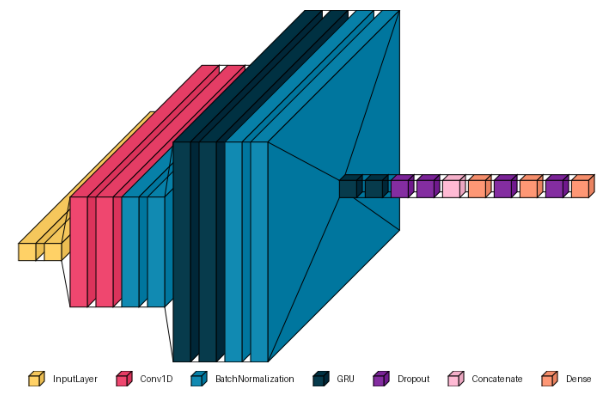

In [24]:
import visualkeras
import matplotlib.pyplot as plt
from PIL import Image

# Save model diagram to file
visualkeras.layered_view(model2, legend=True, draw_volume=True, to_file='model.png')

# Display it inline
img = Image.open('model.png')
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.show()


In [25]:
loss, acc = model2.evaluate([X_test_landmark, X_test_mfcc], y_test)
print(f"Full Test Set Accuracy: {acc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9711 - loss: 0.0738
Full Test Set Accuracy: 0.9699


In [26]:
dummy_mfcc = np.zeros_like(X_test_mfcc)

loss_landmark, acc_landmark = model2.evaluate([X_test_landmark, dummy_mfcc], y_test)
print(f" Facial Landmark Only Test Set Accuracy: {acc_landmark:.4f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8569 - loss: 0.4730
 Facial Landmark Only Test Set Accuracy: 0.8428


In [27]:
dummy_landmark = np.zeros_like(X_test_landmark)

loss_mfcc, acc_mfcc = model2.evaluate([dummy_landmark, X_test_mfcc], y_test)
print(f" MFCC Only Test Set Accuracy: {acc_mfcc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9678 - loss: 0.1840
 MFCC Only Test Set Accuracy: 0.9632
